# Experiment 1 — Predicting the Exact Next-Day SPY Closing Price Using Classical Time-Series Models

**Stock Forecasting Project**

Copyright © 2026 by Tien Le


> **Public Demo Version**
>
> This notebook preserves the original data workflow, model names, training, evaluation, results, and conclusions.
> Only proprietary feature-building formulas and original feature names are omitted where applicable.


# Table of Contents

1. [Introduction](#Introduction)
2. [Motivation](#Motivation)
3. [Research Question](#Research-Question)
4. [Dataset Description](#Dataset-Description)
5. [Methodology](#Methodology)
6. [Data Preparation](#Data-Preparation)
7. [Persistence Baseline](#Persistence-Baseline)
8. [AutoReg Model](#AutoReg-Model)
9. [ARIMA Model](#ARIMA-Model)
10. [SARIMAX Model](#SARIMAX-Model)
11. [Predicting the Daily Price Change](#Predicting-the-Daily-Price-Change)
12. [Model Comparison](#Model-Comparison)
13. [Discussion](#Discussion)
14. [Limitations](#Limitations)
15. [Final Conclusion](#Final-Conclusion)
16. [Next Experiment](#Next-Experiment)


# Introduction

This notebook is the first experiment in a broader stock-market forecasting project. The initial objective is to determine whether classical time-series models can predict the exact next-day closing price of the SPDR S&P 500 ETF Trust (**SPY**).

The study begins with a simple persistence forecast and then evaluates progressively more sophisticated models:

- AutoReg
- ARIMA
- SARIMAX

The models are compared using out-of-sample root mean squared error (**RMSE**) under a chronological train/test split.


# Motivation

Predicting the exact next-day market price is a natural starting point for a forecasting project. Classical time-series models are designed to capture patterns such as autocorrelation, trends, differencing structure, and relationships with external variables.

However, financial markets are highly noisy, and tomorrow's closing price is usually very close to today's closing price. Therefore, a sophisticated model should not be considered useful unless it can outperform a simple persistence forecast:

\[
\widehat{Close}_{t+1} = Close_t
\]

This experiment tests whether AutoReg, ARIMA, or SARIMAX can provide meaningful improvement over that baseline.


# Research Question

> Can classical time-series forecasting models predict the exact next-day SPY closing price more accurately than a simple persistence forecast?

The experiment also investigates two related questions:

1. Does adding autoregressive and moving-average structure improve next-day forecasts?
2. Do exogenous variables from volatility, technology stocks, interest rates, and cryptocurrency provide additional predictive value?


# Dataset Description

The primary target is the daily closing price of **SPY**, which tracks the S&P 500.

Additional market series are downloaded for the SARIMAX experiments:

- **VIX** — CBOE Volatility Index
- **QQQ** — Nasdaq-100 ETF
- **TNX** — 10-Year U.S. Treasury yield
- **BTC-USD** — Bitcoin

The dataset begins on **January 1, 2017**. This period captures multiple market regimes, including the COVID-19 crash and recovery, the 2022 bear market, the AI-driven bull market, and more recent market conditions.


# Methodology

The notebook uses a chronological train/test split so that future observations are never used to train models that predict earlier dates.

The final 5% of the data is reserved for testing. Model performance is measured with RMSE:

\[
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\widehat{y}_i)^2}
\]

Lower RMSE indicates better forecasting performance.

Whenever possible, rolling one-step-ahead forecasting is used. After each prediction, the actual observed value is added to the history before the next forecast is generated. This more closely represents how the model would operate in practice.


# Data Preparation


In [1]:
%pip install yfinance
import yfinance as yf

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Market
spy = yf.download("SPY", start="2017-01-01")
vix = yf.download("^VIX", start="2017-01-01")
qqq = yf.download("QQQ", start="2017-01-01")
tnx = yf.download("^TNX", start="2017-01-01")
btc = yf.download("BTC-USD", start="2017-01-01")
# Leveraged S&P 500 ETFs
spxl = yf.download("SPXL", start="2017-01-01")   # 3x Bull
upro = yf.download("UPRO", start="2017-01-01")   # 3x Bull
sso  = yf.download("SSO",  start="2017-01-01")   # 2x Bull
spxs = yf.download("SPXS", start="2017-01-01")   # 3x Bear

# Stocks
mcd = yf.download("MCD", start="2017-01-01")
mstr = yf.download("MSTR", start="2017-01-01")
pltr = yf.download("PLTR", start="2020-09-30")  # IPO date
tsla = yf.download("TSLA", start="2017-01-01")
wmt = yf.download("WMT", start="2017-01-01")


# Create dictionary containing all downloaded datasets
dictionary = {
    "SPY": spy,
    "VIX": vix,
    "QQQ": qqq,
    "TNX": tnx,
    "BTC": btc,
    "SPXL": spxl,
    "UPRO": upro,
    "SSO": sso,
    "SPXS": spxs,
    "MCD": mcd,
    "MSTR": mstr,
    "PLTR": pltr,
    "TSLA": tsla,
    "WMT": wmt}

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Historical Window

Using more historical data is not always better. Very old observations may reflect market structures, regulations, and trading behavior that are less relevant today.

A start date of 2017 provides several years of data across different market environments while keeping the dataset reasonably representative of current conditions.


In [3]:
print(spy.tail())

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2026-07-06  751.280029  752.409973  747.409973  748.739990  50673300
2026-07-07  747.710022  750.960022  745.210022  750.219971  43721500
2026-07-08  745.400024  746.150024  739.510010  743.159973  43767400
2026-07-09  751.710022  751.969971  745.590027  747.349976  41441700
2026-07-10  754.950012  755.419983  748.099976  752.049988  42114300


In [4]:
print(vix.tail())

Price           Close       High    Low       Open Volume
Ticker           ^VIX       ^VIX   ^VIX       ^VIX   ^VIX
Date                                                     
2026-07-06  15.570000  16.500000  15.56  16.400000      0
2026-07-07  16.129999  16.639999  15.53  15.870000      0
2026-07-08  16.900000  18.910000  16.35  16.549999      0
2026-07-09  15.840000  17.270000  15.76  16.580000      0
2026-07-10  15.030000  16.160000  14.96  16.059999      0


In [5]:
print(btc.tail())

Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2026-07-07  63297.394531  64257.632812  62623.933594  63994.597656   
2026-07-08  62257.574219  63706.886719  61492.648438  63293.519531   
2026-07-09  63193.148438  63422.941406  61645.753906  62257.316406   
2026-07-10  64127.140625  64658.968750  62902.062500  63194.359375   
2026-07-11  63802.027344  64445.460938  63785.621094  64127.968750   

Price            Volume  
Ticker          BTC-USD  
Date                     
2026-07-07  31026493556  
2026-07-08  27349235354  
2026-07-09  26546256117  
2026-07-10  27450201269  
2026-07-11  13954689047  


In [6]:
print(qqq.tail())

Price            Close        High         Low        Open    Volume
Ticker             QQQ         QQQ         QQQ         QQQ       QQQ
Date                                                                
2026-07-06  722.820007  726.080017  718.450012  719.929993  30220400
2026-07-07  709.429993  716.349976  704.900024  714.169983  42483100
2026-07-08  711.440002  712.260010  700.909973  704.950012  35603200
2026-07-09  723.280029  724.229980  715.130005  718.330017  33654700
2026-07-10  725.510010  726.390015  717.000000  720.700012  26374600


In [7]:
print(tnx.tail())

Price       Close   High    Low   Open Volume
Ticker       ^TNX   ^TNX   ^TNX   ^TNX   ^TNX
Date                                         
2026-07-06  4.479  4.491  4.457  4.457      0
2026-07-07  4.529  4.533  4.485  4.497      0
2026-07-08  4.569  4.597  4.557  4.561      0
2026-07-09  4.539  4.581  4.529  4.577      0
2026-07-10  4.569  4.571  4.539  4.541      0


In [8]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [9]:
# Make a function of showing the plot of train, test, and prediction:

def plotTrainTestPred(train, test, pred=None):
    plt.plot(train, label='train')
    plt.plot(test, linewidth=3, label='test', color='yellow')
    if pred is not None:
        plt.plot(pred, linestyle='--', label='predicted', color='black')
        plt.title(f'Compare Train, Test, and Predicted Time Series')
    else:
        plt.title(f'Compare Train and Test Time Series')
    plt.legend()
    plt.grid(True)
    plt.show()

## Chronological Train/Test Split

The first 95% of SPY observations are used for training, and the most recent 5% are held out for testing. The test period is never shuffled because preserving time order is essential for evaluating a forecasting model.


In [10]:
# Split original SPY DataFrame

train_size = int(len(spy) * 0.95)

train = spy.iloc[:train_size]
test = spy.iloc[train_size:]

# Extract Close prices

train_close = train["Close"].squeeze()
test_close = test["Close"].squeeze()

print(f"Number of training dates: {len(train_close)}")
print(f"Number of testing dates: {len(test_close)}")

Number of training dates: 2272
Number of testing dates: 120


In [11]:
print("Train start:", train.index[0])
print("Train end:", train.index[-1])

print("Test start:", test.index[0])
print("Test end:", test.index[-1])

Train start: 2017-01-03 00:00:00
Train end: 2026-01-15 00:00:00
Test start: 2026-01-16 00:00:00
Test end: 2026-07-10 00:00:00


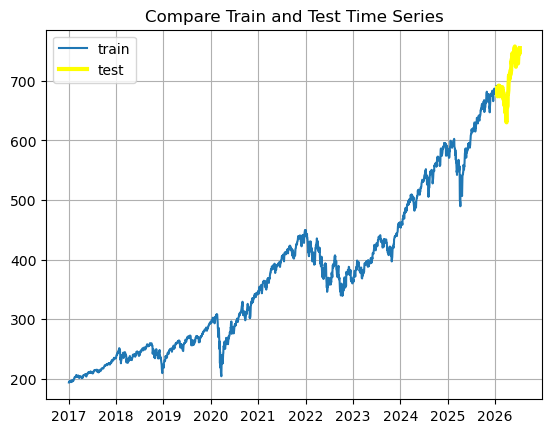

In [12]:
plotTrainTestPred(train_close, test_close)

# Persistence Baseline

Before evaluating more complex models, the project establishes a simple benchmark:

> Tomorrow's closing price is predicted to equal today's closing price.

Because adjacent daily closing prices are usually close, this is a surprisingly difficult baseline to beat.


In [13]:
naive_pred = test_close.shift(1)

rmse_naive = root_mean_squared_error(
    test_close.iloc[1:],
    naive_pred.iloc[1:])

print(f"Trivial Prediction RMSE = {rmse_naive:.4f}")

Trivial Prediction RMSE = 6.3353


The persistence forecast provides the reference RMSE for the remainder of the experiment. A more sophisticated model should only be considered useful if it consistently improves upon this baseline.


# AutoReg Model

The autoregressive order \(p\) determines how many past closing prices are used to predict the next value.

AutoReg is used first because it provides a computationally efficient way to search for a suitable lag length before fitting more expensive ARIMA models.


Best p = 54
Best RMSE = 26.1082


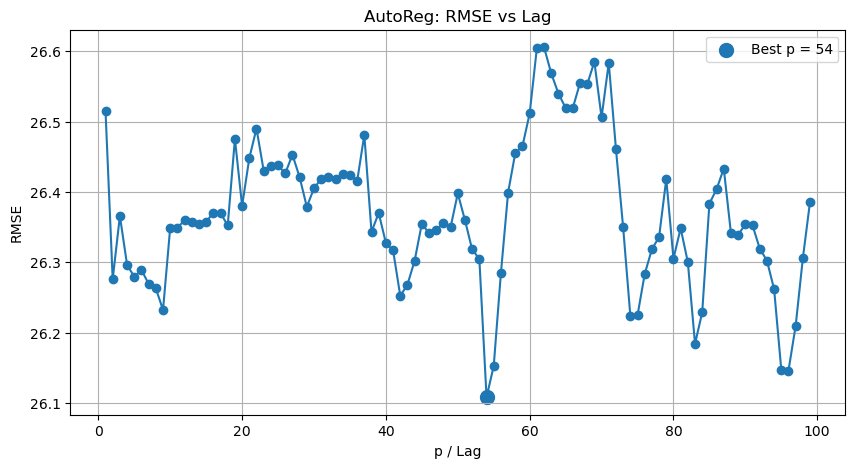

In [14]:
# Find best lag for AutoReg
ar_rmse = {}

for p in range(1, 100):

    try:
        ar = AutoReg(train_close, lags=p)

        ar_fit = ar.fit()

        pred = ar_fit.forecast(steps=len(test_close))

        rmse = root_mean_squared_error(test_close, pred)

        ar_rmse[p] = rmse

    except:
        pass


# Find best p
best_p = min(ar_rmse, key=ar_rmse.get)
best_rmse = ar_rmse[best_p]

print(f"Best p = {best_p}")
print(f"Best RMSE = {best_rmse:.4f}")


# Plot RMSE vs p
plt.figure(figsize=(10, 5))

plt.plot(
    list(ar_rmse.keys()),
    list(ar_rmse.values()),
    marker="o")

plt.scatter(
    best_p,
    best_rmse,
    s=100,
    label=f"Best p = {best_p}")

plt.xlabel("p / Lag")
plt.ylabel("RMSE")
plt.title("AutoReg: RMSE vs Lag")
plt.legend()
plt.grid(True)

plt.show()

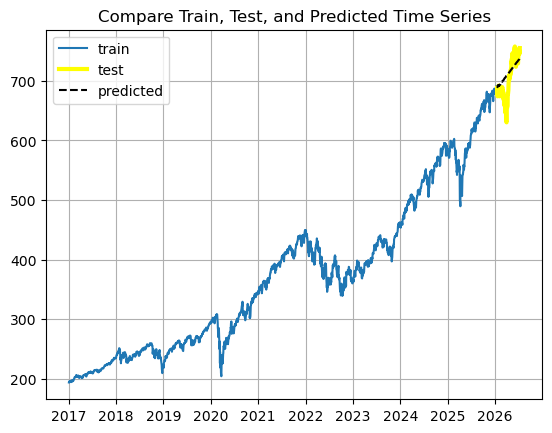

In [15]:
# Create the model and predictions for the lag with the lowest RMSE and show the plot
best_ar = AutoReg(train_close, lags=best_p)
best_ar_fit = best_ar.fit()

best_ar_pred = best_ar_fit.forecast(steps=len(test))

# Make prediction index match test index
best_ar_pred.index = test_close.index

plotTrainTestPred(train_close, test_close, best_ar_pred)

## Rolling One-Step-Ahead AutoReg Forecast

A static multi-step forecast can drift because later predictions depend on earlier predicted values. The rolling forecast instead refits the model after each actual test observation becomes available.


Rolling AutoReg RMSE = 6.3954


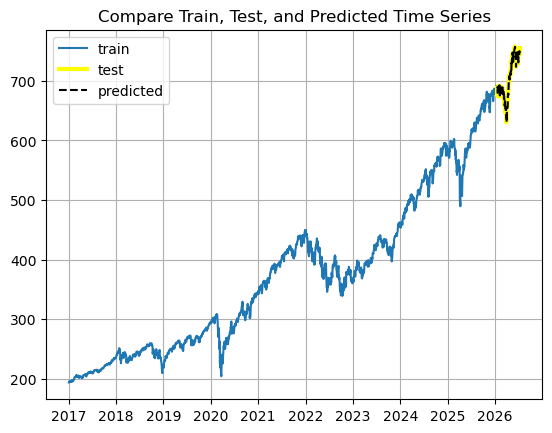

In [16]:
# Rolling one-step-ahead AutoReg prediction

history = train_close.copy()
rolling_pred = []

for i in range(len(test_close)):

    model = AutoReg(history, lags=best_p)
    model_fit = model.fit()

    next_pred = model_fit.forecast(steps=1).iloc[0]
    rolling_pred.append(next_pred)

    # Add the true next test value into history
    history = pd.concat([history, test_close.iloc[i:i+1]])

rolling_pred = pd.Series(rolling_pred, index=test_close.index)

rmse = root_mean_squared_error(test_close, rolling_pred)

print(f"Rolling AutoReg RMSE = {rmse:.4f}")

plotTrainTestPred(train_close, test_close, rolling_pred)

## AutoReg Result

The rolling AutoReg model produced an RMSE of approximately **6.15**, which was slightly worse than the persistence forecast of approximately **6.13**.

This indicates that the autoregressive model did not extract enough short-term structure to improve exact next-day price predictions.


# ARIMA Model

ARIMA extends the autoregressive model with:

- \(p\): autoregressive order
- \(d\): differencing order
- \(q\): moving-average order

The selected AutoReg lag is used as the starting value for \(p\), followed by searches over \(q\) and \(d\).


Testing q=0
RMSE =43.34112346992134
Testing q=1
RMSE =40.11199947192856
Testing q=2
RMSE =39.311455413115965
Testing q=3
RMSE =39.02396962457796
Testing q=4
RMSE =38.81003280948528
Testing q=5
RMSE =37.90913850708768
Best p = 54
Best q = 5
Best RMSE = 37.9091


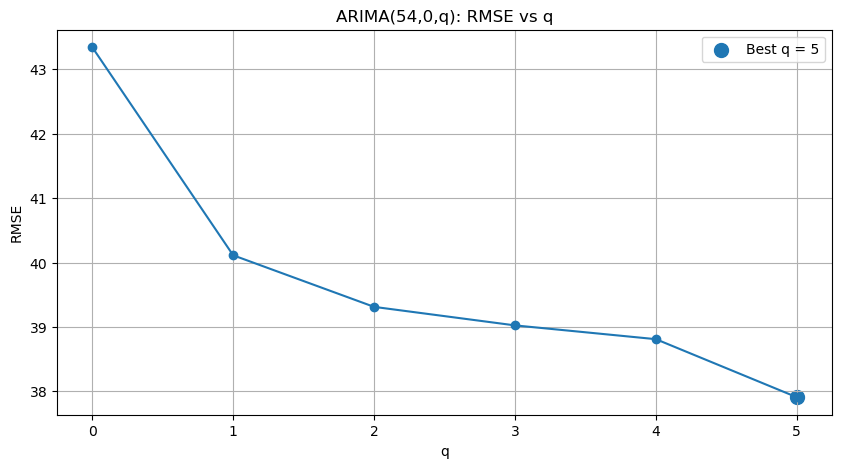

In [17]:
# Find best q for ARIMA(best_p,0,q)
arma_rmse = {}

for q in range(0, 6):

    try:
        arma = ARIMA(
            train_close,
            order=(best_p, 0, q))

        arma_fit = arma.fit()

        pred = arma_fit.forecast(steps=len(test_close))

        rmse = root_mean_squared_error(test_close, pred)

        arma_rmse[q] = rmse

        print(f"Testing q={q}")
        print(f"RMSE ={rmse}")

    except:
        pass

# Find best q

best_q = min(arma_rmse, key=arma_rmse.get)
best_rmse = arma_rmse[best_q]

print(f"Best p = {best_p}")
print(f"Best q = {best_q}")
print(f"Best RMSE = {best_rmse:.4f}")


# Plot RMSE vs q

plt.figure(figsize=(10, 5))

plt.plot(
    list(arma_rmse.keys()),
    list(arma_rmse.values()),
    marker="o")

plt.scatter(
    best_q,
    best_rmse,
    s=100,
    label=f"Best q = {best_q}")

plt.xlabel("q")
plt.ylabel("RMSE")
plt.title(f"ARIMA({best_p},0,q): RMSE vs q")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
# Find best d for ARIMA(best_p,d,best_q)

d_rmse = {}

for d in range(0, 3):

    print(f"Testing d={d}")

    try:
        arima = ARIMA(
            train_close,
            order=(best_p, d, best_q))

        arima_fit = arima.fit()

        pred = arima_fit.forecast(
            steps=len(test_close))

        pred.index = test_close.index

        rmse = root_mean_squared_error(test_close, pred)

        d_rmse[d] = rmse

        print(f"RMSE = {rmse:.4f}")

    except Exception as e:
        print(f"d={d} failed")
        print(e)


# Find best d

best_d = min(d_rmse, key=d_rmse.get)
best_arima_rmse = d_rmse[best_d]

print(f"Best p = {best_p}")
print(f"Best d = {best_d}")
print(f"Best q = {best_q}")
print(f"Best ARIMA RMSE = {best_arima_rmse:.4f}")

Testing d=0
RMSE = 37.9091
Testing d=1
RMSE = 37.0988
Testing d=2
RMSE = 26.7643
Best p = 54
Best d = 2
Best q = 5
Best ARIMA RMSE = 26.7643


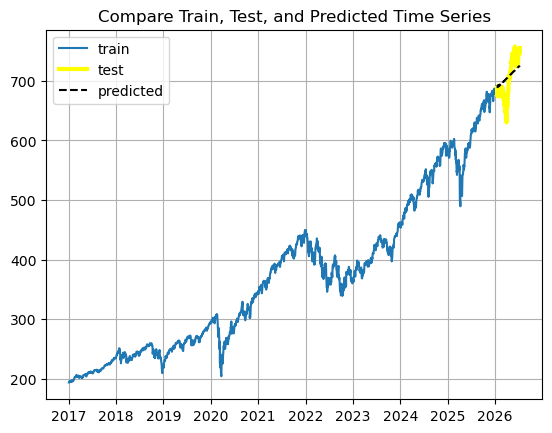

In [19]:
# Fit final ARIMA model

final_arima = ARIMA(
    train_close,
    order=(best_p, best_d, best_q))

final_arima_fit = final_arima.fit()

final_arima_pred = final_arima_fit.forecast(steps=len(test_close))

final_arima_pred.index = test_close.index


# Plot train, test, and prediction

plotTrainTestPred(train_close, test_close, final_arima_pred)

## Rolling One-Step-Ahead ARIMA Forecast


In [ ]:
# Rolling one-step-ahead ARIMA prediction

history = train_close.copy()
rolling_arima_pred = []

for i in range(len(test_close)):

    model = ARIMA(history, order=(best_p, best_d, best_q))

    model_fit = model.fit()

    next_pred = model_fit.forecast(steps=1).iloc[0]

    rolling_arima_pred.append(next_pred)

    # Add the true next test value into history
    history = pd.concat([history, test_close.iloc[i:i+1]])


rolling_arima_pred = pd.Series(rolling_arima_pred, index=test_close.index)

rolling_arima_rmse = root_mean_squared_error(test_close, rolling_arima_pred)

print(f"Rolling ARIMA({best_p},{best_d},{best_q}) RMSE = {rolling_arima_rmse:.4f}")

plotTrainTestPred(train_close,test_close,rolling_arima_pred)

In [ ]:
plt.plot(
    test_close,
    label="test",
    color="yellow",
    linewidth=3)

plt.plot(
    rolling_arima_pred,
    label="predicted",
    color="black",
    linestyle="--")

plt.legend()
plt.grid()
plt.show()

In [ ]:
plt.plot(
    test_close.iloc[-10:],
    label="test",
    color="yellow",
    linewidth=3)

plt.plot(
    rolling_arima_pred.iloc[-10:],
    label="predicted",
    color="black",
    linestyle="--")

plt.legend()
plt.grid()
plt.show()

## ARIMA Result

The rolling ARIMA model achieved an RMSE of approximately **6.17**. It was slightly worse than both the rolling AutoReg model and the persistence baseline.

The result suggests that differencing and moving-average error terms did not provide meaningful additional forecasting power for the exact next-day SPY closing price. The rolling procedure was also computationally expensive.


# SARIMAX Model

SARIMAX extends ARIMA by incorporating exogenous variables. This experiment uses contemporaneous market information from SPY, VIX, QQQ, TNX, and Bitcoin.

The first implementation is intentionally examined for data leakage because using future exogenous values would make the apparent performance unrealistic.


In [ ]:
# Create SARIMAX dataframe
sarimax_df = pd.DataFrame({

    # Target
    "SPY_Close": spy["Close"].squeeze(),

    # SPY features
    "SPY_Open": spy["Open"].squeeze(),
    "SPY_High": spy["High"].squeeze(),
    "SPY_Low": spy["Low"].squeeze(),
    "SPY_Volume": spy["Volume"].squeeze(),

    # Market features
    "VIX_Close": vix["Close"].squeeze(),
    "QQQ_Close": qqq["Close"].squeeze(),

    # Additional features
    "TNX_Close": tnx["Close"].squeeze(),
    "BTC_Close": btc["Close"].squeeze()

}).dropna()

In [ ]:
print(sarimax_df.shape)
display(sarimax_df.head())

## Initial SARIMAX Specification

The SARIMAX model is first trained using the ARIMA orders selected above.


In [ ]:
# Target variable 
y = sarimax_df["SPY_Close"]

# Exogenous variables 
X = sarimax_df.drop(columns=["SPY_Close"])

# Split train/test
train_size = int(len(sarimax_df) * 0.95)

train_y = y[:train_size]
test_y = y[train_size:]

train_X = X[:train_size]
test_X = X[train_size:]

In [ ]:
# Fit SARIMAX model

sarimax = SARIMAX(
    train_y,
    exog=train_X,
    order=(best_p, best_d, best_q))

sarimax_fit = sarimax.fit()

print(sarimax_fit.summary())

In [ ]:
# Predict test period

sarimax_pred = sarimax_fit.forecast(
    steps=len(test_y),
    exog=test_X)

# Match test index
sarimax_pred.index = test_y.index

# Calculate RMSE

sarimax_rmse = root_mean_squared_error(
    test_y,
    sarimax_pred)

print(f"SARIMAX RMSE = {sarimax_rmse:.4f}")

plotTrainTestPred(train_y, test_y, sarimax_pred)

In [ ]:
plt.plot(
    test_y,
    label="test",
    color="yellow",
    linewidth=3)

plt.plot(
    sarimax_pred,
    label="predicted",
    color="black",
    linestyle="--")

plt.legend()
plt.grid()
plt.show()

## Data-Leakage Check

The initial SARIMAX forecast uses exogenous variables from the same future date as the target. Those future values would not be known at prediction time.

For example, tomorrow's high, low, volume, VIX, interest rate, and Bitcoin price cannot be used today to make a realistic forecast of tomorrow's SPY close. This introduces look-ahead bias.

To correct the problem, the target is shifted so that today's known market variables are used to predict tomorrow's SPY closing price.


## Realistic Next-Day SARIMAX Forecast


In [ ]:
# Create tomorrow's SPY close as the target
sarimax_df["Target"] = sarimax_df["SPY_Close"].shift(-1)

# Remove last row because tomorrow's close is unknown
sarimax_df = sarimax_df.dropna()

# Target variable = tomorrow's SPY close
y = sarimax_df["Target"]

# Features = today's information
X = sarimax_df.drop(
    columns=[
        "Target",
        "SPY_Close"])

# Split train/test
train_size = int(len(sarimax_df) * 0.95)

train_y = y[:train_size]
test_y = y[train_size:]

train_X = X[:train_size]
test_X = X[train_size:]

In [ ]:
# Fit SARIMAX model

sarimax = SARIMAX(
    train_y,
    exog=train_X,
    order=(best_p, best_d, best_q))

sarimax_fit = sarimax.fit()

print(sarimax_fit.summary())

In [ ]:
# Predict test period

sarimax_pred = sarimax_fit.forecast(
    steps=len(test_y),
    exog=test_X)

# Match test index
sarimax_pred.index = test_y.index

# Calculate RMSE

sarimax_rmse = root_mean_squared_error(
    test_y,
    sarimax_pred)

print(f"SARIMAX RMSE = {sarimax_rmse:.4f}")

plotTrainTestPred(train_y, test_y, sarimax_pred)

In [ ]:
plt.plot(
    test_y,
    label="test",
    color="yellow",
    linewidth=3)

plt.plot(
    sarimax_pred,
    label="predicted",
    color="black",
    linestyle="--")

plt.legend()
plt.grid()
plt.show()

## SARIMAX Result

After the timing alignment is corrected, the SARIMAX RMSE increases dramatically to approximately **198.66**.

This is the worst result among the tested models. It indicates that the exogenous variables, when restricted to information actually available at prediction time, do not provide useful support for forecasting the exact next-day SPY closing price in this specification.


# Predicting the Daily Price Change

Because exact price levels are strongly influenced by today's closing price, an additional experiment predicts the change in SPY from today to tomorrow:

\[
Change_{t+1}=Close_{t+1}-Close_t
\]

This reframing tests whether SARIMAX can capture the smaller day-to-day movement directly.


In [ ]:
# Create target: tomorrow's SPY close change
sarimax_df["Target_Change"] = (
    sarimax_df["SPY_Close"].shift(-1) - sarimax_df["SPY_Close"]
)

# Drop last row because tomorrow's close is unknown
model_df = sarimax_df.dropna()

# Target = tomorrow's price change
y = model_df["Target_Change"]

# Features = today's information
X = model_df.drop(columns=["Target_Change"])

# Split train/test
train_size = int(len(model_df) * 0.95)

train_y = y[:train_size]
test_y = y[train_size:]

train_X = X[:train_size]
test_X = X[train_size:]

In [ ]:
sarimax_change = SARIMAX(
    train_y,
    exog=train_X,
    order=(1, 0, 0)   # start simple
)

sarimax_change_fit = sarimax_change.fit()

change_pred = sarimax_change_fit.forecast(
    steps=len(test_y),
    exog=test_X
)

change_pred.index = test_y.index

change_rmse = root_mean_squared_error(test_y, change_pred)

print(f"SARIMAX Change RMSE = {change_rmse:.4f}")

In [ ]:
plt.plot(test_y, label="Actual Change", color="yellow", linewidth=3)
plt.plot(change_pred, label="Predicted Change", color="black", linestyle="--")

plt.title("SARIMAX: Actual vs Predicted SPY Close Change")
plt.legend()
plt.grid()
plt.show()

The model predicts changes close to zero for most observations. In practice, this behaves like another persistence forecast and fails to identify meaningful daily price movements.


# Model Comparison

| Model | Approximate Test RMSE | Interpretation |
|---|---:|---|
| Persistence forecast | 6.13 | Strong simple baseline |
| Rolling AutoReg | 6.15 | Slightly worse than persistence |
| Rolling ARIMA | 6.17 | No improvement over AutoReg or persistence |
| Initial SARIMAX | 10.27 | Uses unavailable future exogenous values |
| Corrected SARIMAX | 198.66 | Very poor realistic next-day forecast |
| SARIMAX on price change | Predicts near zero | Does not capture meaningful daily movement |

The exact values may vary slightly when the notebook is rerun because Yahoo Finance may update historical adjustments or append new trading days.


# Discussion

Several important lessons emerge from this experiment.

First, a simple persistence forecast is extremely competitive for next-day closing-price prediction. Because tomorrow's closing price is usually close to today's, a low RMSE does not necessarily imply that a model has learned meaningful market behavior.

Second, increasing model complexity did not improve performance. AutoReg, ARIMA, and SARIMAX all failed to beat the persistence baseline under realistic conditions.

Third, the SARIMAX experiment demonstrates the importance of preventing data leakage. A model may appear stronger when future exogenous values are supplied, but such a forecast cannot be reproduced in live use.

Finally, predicting exact prices may not be the most useful formulation of the problem. Investment decisions often depend more on direction, downside risk, or unusually large moves than on the exact closing value.


# Limitations

- The test set represents only the most recent 5% of observations.
- The models use daily data and may miss intraday information.
- ARIMA orders are selected through a limited search because rolling estimation is computationally expensive.
- SARIMAX assumes a mostly linear relationship between the target and exogenous variables.
- Transaction costs, slippage, and trading decisions are outside the scope of this experiment.
- RMSE measures numerical closeness but does not directly measure whether the predicted market direction is correct.


# Final Conclusion

Overall, none of the classical time-series forecasting models—including AutoReg, ARIMA, and SARIMAX—demonstrated meaningful predictive improvement over a simple persistence forecast that assumes tomorrow's closing price will equal today's closing price.

The rolling AutoReg and ARIMA models produced RMSE values close to, but slightly worse than, the persistence baseline. SARIMAX also failed to improve the forecast. Once future exogenous information was removed and the model was evaluated under realistic timing constraints, its performance deteriorated substantially. Predicting the next-day price change directly also produced forecasts close to zero and did not capture meaningful market movements.

These results suggest that predicting the exact next-day SPY closing price is extremely difficult using traditional time-series models. The main challenge is not simply selecting a more complex model; it is that short-term price changes contain substantial noise and limited predictable structure.


# Next Experiment

The next experiment reformulates the problem as a classification task.

Instead of predicting the exact numerical closing price, the model will predict whether SPY will move **Up** or **Down** on the following trading day using SPY candlestick, price-action, volume, and technical-indicator features.

This change allows the project to evaluate whether machine-learning classifiers can identify directional information even when exact price forecasting is unsuccessful.
